In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nelgiriyewithana_emotions_path = kagglehub.dataset_download('nelgiriyewithana/emotions')

print('Data source import complete.')


Using Colab cache for faster access to the 'emotions' dataset.
Data source import complete.


# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Emotions Analysis | Bidirectional GRU | 0.94 Train |0.93 Test</p>

***We will do The Following Tasks in this Notebook to train a Bidirectional GRU on Emotion Analysis :***
- We Will Load Textual data and preprocess and clean the texts.
- We will do Tokenization and inter encoding using Tokeinzer Class.
- We will do Padding .
- We Will Train a Bidirectional GRU. to Get good Accuracy.
- We Will Visualize Results.
- Do Evaluations on Test Data.

![Emotions Analysis (1).png](attachment:4ad28ec5-0834-4169-870d-eefc419f3099.png)

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">About Dataset</p>

## Introduction:
Welcome to the "Emotions" dataset – a collection of English Twitter messages meticulously annotated with six fundamental emotions: anger, fear, joy, love, sadness, and surprise. This dataset serves as a valuable resource for understanding and analyzing the diverse spectrum of emotions expressed in short-form text on social media.

## About the Dataset:
Each entry in this dataset consists of a text segment representing a Twitter message and a corresponding label indicating the predominant emotion conveyed. The emotions are classified into six categories: sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5). Whether you're interested in sentiment analysis, emotion classification, or text mining, this dataset provides a rich foundation for exploring the nuanced emotional landscape within the realm of social media.

## Key Features:
- text: A string feature representing the content of the Twitter message.
- label: A classification label indicating the primary emotion, with values ranging from 0 to 5.
## Potential Use Cases:
Sentiment Analysis: Uncover the prevailing sentiments in English Twitter messages across various emotions.
Emotion Classification: Develop models to accurately classify tweets into the six specified emotion categories.
Textual Analysis: Explore linguistic patterns and expressions associated with different emotional states.
## Sample Data:
| text                                           | label |
|------------------------------------------------|-------|
| that was what i felt when i was finally accept…| 1     |
| i take every day as it comes i'm just focussin…| 4     |
| i give you plenty of attention even when i fee…| 0     |

If you find this dataset useful consider giving it a vote! 😊❤️

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">About Author</p>
##### ***Hello, I'm  Muhammad_Abdullah : A Data Science Enthusiast and Kaggle 2x Expert***

Greetings! I'm delighted to welcome you into my world of data science exploration and innovation. I'm **Muhammad_Abdullah**, a passionate data scientist with a fervent dedication to unraveling the mysteries hidden within datasets and leveraging the power of machine learning to drive meaningful insights and solutions.

###### ***A Passion for Data Science***

Since the inception of my journey into the captivating realm of data science, I've been driven by an insatiable curiosity and an unwavering passion for uncovering the stories embedded in data. From the thrill of diving deep into complex datasets to the exhilaration of crafting predictive models that shape our understanding of the world, data science has become not just a profession but a lifelong passion.

###### ***Guiding Light on Kaggle***

As a Kaggle 2x Expert, I've had the privilege of sharing my knowledge, insights, and experiences with the vibrant Kaggle community. Through meticulously crafted notebooks, engaging discussions, and collaborative projects, I've had the opportunity to mentor aspiring data enthusiasts, foster a culture of learning and growth, and contribute to the collective pursuit of excellence in data science.

###### ***Let's Explore Together***

Join me on an exhilarating adventure into the dynamic world of data science! Together, we'll unlock the potential of data, unravel its mysteries, and embark on a transformative journey of discovery and innovation. Whether you're a seasoned data enthusiast or just beginning your data science odyssey, I'm excited to share this journey with you and explore the endless possibilities that data science has to offer.
<div style="text-align: left;">
    <table>
        <tr>
            <th><b>Website</b></th>
            <th><b>Links</b></th>
        </tr>
        <tr>
        </tr>
        <tr>
            <td>GitHub</td>
            <td><a href="https://github.com/muhammadabdullah0303"><img src="https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github" alt="GitHub"/></a></td>
        </tr>
        <tr>
            <td>LinkedIn</td>
            <td><a href="https://www.linkedin.com/in/muhammad-abdullah-6b84b4297/"><img src="https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin" alt="LinkedIn"/></a></td>
        </tr>
        <tr>
        </tr>
        <tr>
            <td>Facebook</td>
            <td><a href="https://web.facebook.com/abd.sentaflexmental"><img src="https://img.shields.io/badge/Facebook-Profile-blue?style=for-the-badge&logo=facebook" alt="Facebook"/></a></td>
        </tr>
        <tr>
            <td>Gmail</td>
            <td><a href="mailto:mrabdullah@gmail.com"><img src="https://img.shields.io/badge/Gmail-Contact%20Me-red?style=for-the-badge&logo=gmail" alt="Gmail"/></a></td>
        </tr>
    </table>
</div>


# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Importing Libraries</p>

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Word Cloud
from wordcloud import WordCloud
# from textacy import preprocessing
from nltk.stem.snowball import SnowballStemmer
from keras.preprocessing import sequence
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import re

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Loading Data</p>


In [5]:
# Load Data
df = pd.read_csv('HateDS.csv')
# Drop rows where the 'label' column has NaN values
#df.dropna(subset=['label'], inplace=True)
df.head()

,tweet,label
0,"""@DreadheadAri: she really asked me that dead ...",F
1,&#8000;@SoDamnTrue: I live in constant fear of...,F
2,&#8000;@_Dominiquecs: @Thompson_Era hahaha! Sh...,F
3,&#8000;@dreadHEADkidd69: pussy prolly taste li...,F
4,@DreadHeadxx bitch hallon,F


In [6]:
# Shape Of Data
print(f'The Shape Of Data Is : {df.shape}')

The Shape Of Data Is : (46593, 2)


In [7]:
# Null Values
df.isnull().sum()

,0
tweet,0
label,0


In [8]:
# Duplicates
df.duplicated().sum()

np.int64(13974)

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Renaming The Columns Names</p>


In [ ]:
# Rename Columns
df.rename(columns={'tweet': 'text', 'label': 'Label'}, inplace=True)
# Dropping the Index Colums
#df.drop('Unnamed: 0',axis=1,inplace=True)

In [9]:
# Head Of Data
df.head()

,tweet,label
0,"""@DreadheadAri: she really asked me that dead ...",F
1,&#8000;@SoDamnTrue: I live in constant fear of...,F
2,&#8000;@_Dominiquecs: @Thompson_Era hahaha! Sh...,F
3,&#8000;@dreadHEADkidd69: pussy prolly taste li...,F
4,@DreadHeadxx bitch hallon,F


# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Label Count</p>


/tmp/ipykernel_854/3175363569.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count.index, y=count.values, ax=axs[1], palette="viridis")


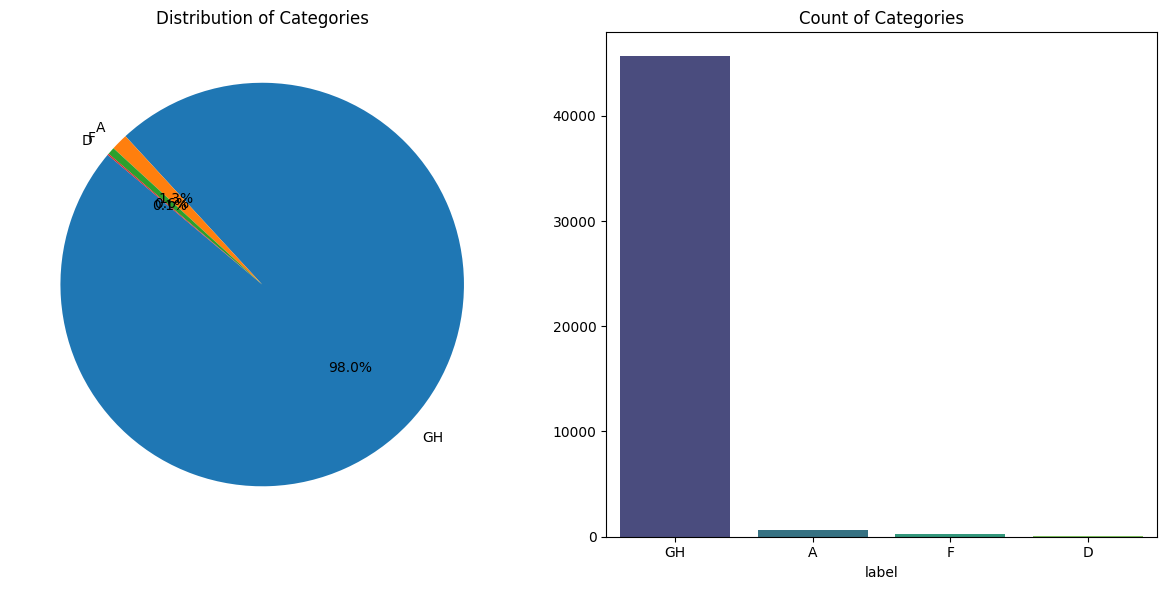

In [11]:
# Value Count Of Label
count = df['label'].value_counts()

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

# Plot pie chart on the first subplot
palette = sns.color_palette("viridis")
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories')

# Plot bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette="viridis")
axs[1].set_title('Count of Categories')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Two Seperate Data Set for Visualizng text</p>

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Visualizing Text Using Word Cloud</p>

***A word cloud is a visual representation of text data in which the frequency of each word's occurrence is depicted by the size of the word. Words that appear more frequently in the text are typically displayed with a larger font size, while less frequent words are smaller.***

***Word clouds are often used to quickly and visually summarize the most common words or themes within a large body of text. They are popular in data analysis, text mining, and visualization tasks, as they provide a simple yet effective way to identify patterns and trends in textual data.***

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Encode Label again</p>

In [ ]:
# Now Unrename Label again
# Note: This block now explicitly remaps labels based on unique values found in the 'Label' column.
# The previous individual `replace` calls have been replaced by a more robust mapping approach.

# Get unique sorted labels
unique_labels = sorted(df['Label'].dropna().unique())
# Create a mapping from old labels to new 0-indexed labels
label_mapping = {label: i for i, label in enumerate(unique_labels)}
df['Label'] = df['Label'].map(label_mapping)

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Text Preprocessing</p>

1. **Step 1: Remove URLs:** Uses a regular expression to remove URLs from the text data.

2. **Step 2: Remove special characters and punctuation:** Uses a regular expression to remove any special characters and punctuation marks from the text.

3. **Step 3: Remove extra whitespaces:** Uses a regular expression to remove extra whitespaces and replace them with a single space.

4. **Step 4: Remove numeric values:** Uses a regular expression to remove any numeric values from the text.

5. **Step 6: Lowercasing:** Converts all text to lowercase to ensure consistency.

6. **Step 8: Remove stop words:** Removes common English stop words, such as "the," "is," "and," etc., using NLTK's stopwords list.

7. **Step 9: Remove non-alphanumeric characters:** Uses a regular expression to remove any non-alphanumeric characters from the text.

***Overall, these preprocessing steps help clean and normalize the text data, removing noise and ensuring that the data is consistent and suitable for further analysis or modeling tasks.***

In [12]:
# Import Basis Needed Libaries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK resources (uncomment the following line if not already downloaded)?
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Url's</p>

In [13]:
# Step 1: Remove URLs
df['tweet'] = df['tweet'].str.replace(r'http\S+', '', regex=True)

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                               tweet label
0  "@DreadheadAri: she really asked me that dead ...     F
1  &#8000;@SoDamnTrue: I live in constant fear of...     F
2  &#8000;@_Dominiquecs: @Thompson_Era hahaha! Sh...     F
3  &#8000;@dreadHEADkidd69: pussy prolly taste li...     F
4                          @DreadHeadxx bitch hallon     F


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Special Characters and Punctuation</p>

In [14]:
# Step 2: Remove special characters and punctuation
df['tweet'] = df['tweet'].str.replace(r'[^\w\s]', '', regex=True)

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                               tweet label
0  DreadheadAri she really asked me that dead ass...     F
1  8000SoDamnTrue I live in constant fear of bein...     F
2  8000_Dominiquecs Thompson_Era hahaha She to mu...     F
3  8000dreadHEADkidd69 pussy prolly taste like he...     F
4                           DreadHeadxx bitch hallon     F


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove WhiteSpaces Extra's</p>

In [15]:
# Step 3: Remove extra whitespaces
df['tweet'] = df['tweet'].str.replace(r'\s+', ' ', regex=True)

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                               tweet label
0  DreadheadAri she really asked me that dead ass...     F
1  8000SoDamnTrue I live in constant fear of bein...     F
2  8000_Dominiquecs Thompson_Era hahaha She to mu...     F
3  8000dreadHEADkidd69 pussy prolly taste like he...     F
4                           DreadHeadxx bitch hallon     F


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Numeric Values in Text</p>

In [16]:
# Step : 4 Remove numeric values
df['tweet'] = df['tweet'].str.replace(r'\d+', '', regex=True)

# Head
df.head()

,tweet,label
0,DreadheadAri she really asked me that dead ass...,F
1,SoDamnTrue I live in constant fear of being sh...,F
2,_Dominiquecs Thompson_Era hahaha She to much o...,F
3,dreadHEADkidd pussy prolly taste like heaven,F
4,DreadHeadxx bitch hallon,F


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Lower Casing text</p>

In [17]:
# Step 6: Lowercasing
df['tweet'] = df['tweet'].str.lower()

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                               tweet label
0  dreadheadari she really asked me that dead ass...     F
1  sodamntrue i live in constant fear of being sh...     F
2  _dominiquecs thompson_era hahaha she to much o...     F
3     dreadheadkidd pussy prolly taste like heaven       F
4                           dreadheadxx bitch hallon     F


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Stopwords</p>

In [18]:
# Step 8: Remove stop words
stop = stopwords.words('english')
df["tweet"] = df['tweet'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

# Display the first few rows of the DataFrame to verify the changes
df.head()

,tweet,label
0,dreadheadari really asked dead ass serious tho...,F
1,sodamntrue live constant fear shit bird well a...,F
2,_dominiquecs thompson_era hahaha much thottie ...,F
3,dreadheadkidd pussy prolly taste like heaven,F
4,dreadheadxx bitch hallon,F


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Non-alpha Numeric</p>

In [19]:
# Step : 9 Remove non-alphanumeric characters from the 'Text' column
df['tweet'] = df['tweet'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

# Display the first few rows of the DataFrame to verify the changes
df.head()

,tweet,label
0,dreadheadari really asked dead ass serious tho...,F
1,sodamntrue live constant fear shit bird well a...,F
2,dominiquecs thompsonera hahaha much thottie ne...,F
3,dreadheadkidd pussy prolly taste like heaven,F
4,dreadheadxx bitch hallon,F


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Train Test Split</p>

In [21]:
X = df['tweet']
y = df['label']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (37274,)
X_test shape: (9319,)
y_train shape: (37274,)
y_test shape: (9319,)


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Tokenization and Padding Sequences</p>

#### 1. ***Tokenization:*** ***The text data in `X_train` and `X_test` is tokenized using the Tokenizer class from Keras. This step converts the text data into sequences of integers, where each unique word in the dataset is assigned a unique integer index. The `num_words` parameter limits the vocabulary size to 50,000 most frequent words.***

#### 2. ***Padding:*** ***After tokenization, the sequences in `X_train` and `X_test` are padded to ensure uniform length. This is achieved using the pad_sequences function, which pads sequences with zeros to make them all of the same length (`maxlen`). Padding is done after the sequences to ensure that the actual content of the text is preserved.***

***Overall, the code prepares the text data for further processing and modeling by converting it into tokenized and padded sequences, making it suitable for use in machine learning algorithms such as neural networks.***

In [22]:
# Tokenize the text data
tokenizer = Tokenizer(num_words=50000)
tokenizer.fit_on_texts(X_train) # Fit only on training data
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test) # Transform test data using the fitted tokenizer

In [23]:
# Max Len in X_train_sequences
maxlen = max(len(tokens) for tokens in X_train_sequences)
print("Maximum sequence length (maxlen):", maxlen)

Maximum sequence length (maxlen): 25


In [24]:
# Perform padding on X_train and X_test sequences
X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=maxlen, padding='post')

# Print the padded sequences for X_train and X_test
print("X_train_padded:")
print(X_train_padded)
print("\nX_test_padded:")
print(X_test_padded)

X_train_padded:
[[    2  3737  2868 ...     0     0     0]
 [21306  2098   257 ...     0     0     0]
 [  638    11     5 ...     0     0     0]
 ...
 [    2 31370     2 ...     0     0     0]
 [   86    51   164 ...     0     0     0]
 [    2  3676   592 ...     0     0     0]]

X_test_padded:
[[    2  4019   125 ...     0     0     0]
 [    2 19782    14 ...     0     0     0]
 [25770  2763 25771 ...     0     0     0]
 ...
 [27049   111     5 ...     0     0     0]
 [   87   289     6 ...     0     0     0]
 [23350  8761  5540 ...     0     0     0]]


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Input Size</p>

In [25]:
# Embedding Input Size / Vocabulary Size
input_Size = np.max(X_train_padded) + 1
print(f"Input Size (Vocabulary Size): {input_Size}")

Input Size (Vocabulary Size): 31371


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Model Building</p>

![image.png](attachment:33ff61ab-c4a4-42eb-a003-b8cd059a13d6.png)

***I am Using BiDirectional GRU Here To Get Better Performence.Bidirectional Gated Recurrent Units (GRUs) are essential in natural language processing and sequence modeling tasks due to their ability to capture bidirectional dependencies in sequential data. Unlike traditional unidirectional models, which only process data in one direction (either forward or backward), bidirectional GRUs process input sequences in both directions simultaneously. This allows them to incorporate information from past and future context, enabling more comprehensive understanding and representation of the input sequence. By considering context from both directions, bidirectional GRUs excel in capturing long-range dependencies, especially in tasks where context plays a crucial role, such as sentiment analysis, machine translation, and named entity recognition. This bidirectional processing capability enhances model performance by capturing more nuanced relationships within the data, leading to improved accuracy and robustness in various sequence modeling tasks.***

- `model = Sequential()` initializes a sequential model, allowing layers to be added in sequence.

- The `Embedding` layer is added to the model. It is responsible for converting input integers (each representing a word index) into dense vectors of fixed size. This layer is essential for handling textual data.

- `Dropout` layer with a dropout rate of 0.5 is added next. Dropout layers help prevent overfitting by randomly setting a fraction of input units to zero during training.

- Two Bidirectional GRU layers are added sequentially. Bidirectional layers process the input sequence in both directions, allowing the model to capture information from past and future states. The `return_sequences=True` argument ensures that the output sequences are returned for each timestep.

- `BatchNormalization` layer is added to normalize the activations of the previous layer at each batch, aiding in faster and more stable training.

- Another Bidirectional GRU layer is added to capture bidirectional dependencies more effectively.

- The final `Dense` layer with 6 units (for 6 classes) and softmax activation function is added as the output layer for multi-class classification.

- The model is compiled with the Adam optimizer, sparse categorical crossentropy loss function, and accuracy as the evaluation metric.

- `model.summary()` prints the summary of the model, displaying the architecture and parameter details.

In [27]:
import numpy as np

# Define the model
model = Sequential()

# Add embedding layer
model.add(Embedding(input_dim=input_Size, output_dim=50, input_length=maxlen))

# Dropout
model.add(Dropout(0.5))

# Add Bidirectional LSTM layer
model.add(Bidirectional(GRU(120, return_sequences=True)))
model.add(Bidirectional(GRU(64, return_sequences=True)))
#added
model.add(GRU(units=64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))



#Batch Normalization
model.add(BatchNormalization())

# Add Bidirectional GRU layer
model.add(Bidirectional(GRU(64)))

# Fix for NameError: 'unique_labels' not defined.
# The 'unique_labels' variable was intended to be derived from the 'Label' column
# after renaming and mapping. However, based on the current kernel state,
# the 'df' DataFrame still contains a 'label' column with string values
# ('GH', 'A', 'F', 'D') and 'unique_labels' is not defined.
# We will derive the number of classes directly from the 'label' column in 'df'
# which is available in the kernel state.
num_classes = len(df['label'].unique())

# Add output layer. The number of units should be equal to the number of unique labels after remapping.
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Model Fitting</p>

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

# 3. Configure Early Stopping
# 'patience' is the number of epochs to wait for improvement
early_stopping = EarlyStopping(
    monitor='val_loss',  # Metric to monitor
    patience=10,         # Number of epochs with no improvement to wait
    restore_best_weights=True  # Restore the best model weights
)

# Fix: Map string labels to integers before converting to int dtype
# Get unique sorted string labels from the training set
unique_string_labels = sorted(y_train.unique())
# Create a mapping from string labels to 0-indexed integers
label_to_int_mapping = {label: i for i, label in enumerate(unique_string_labels)}

# Apply the mapping to y_train and y_test
y_train_processed = y_train.map(label_to_int_mapping).astype(int)
y_test_processed = y_test.map(label_to_int_mapping).astype(int)

# Model Train
history = model.fit(X_train_padded, y_train_processed, epochs=5, batch_size=1500, validation_data=(X_test_padded, y_test_processed))

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.9406 - loss: 0.2157 - val_accuracy: 0.9796 - val_loss: 0.3672
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9797 - loss: 0.1162 - val_accuracy: 0.9796 - val_loss: 0.3285
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9797 - loss: 0.1122 - val_accuracy: 0.9796 - val_loss: 0.2716
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9797 - loss: 0.0981 - val_accuracy: 0.9796 - val_loss: 0.2259
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9845 - loss: 0.0557 - val_accuracy: 0.9835 - val_loss: 0.0830


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Visualizing Results</p>

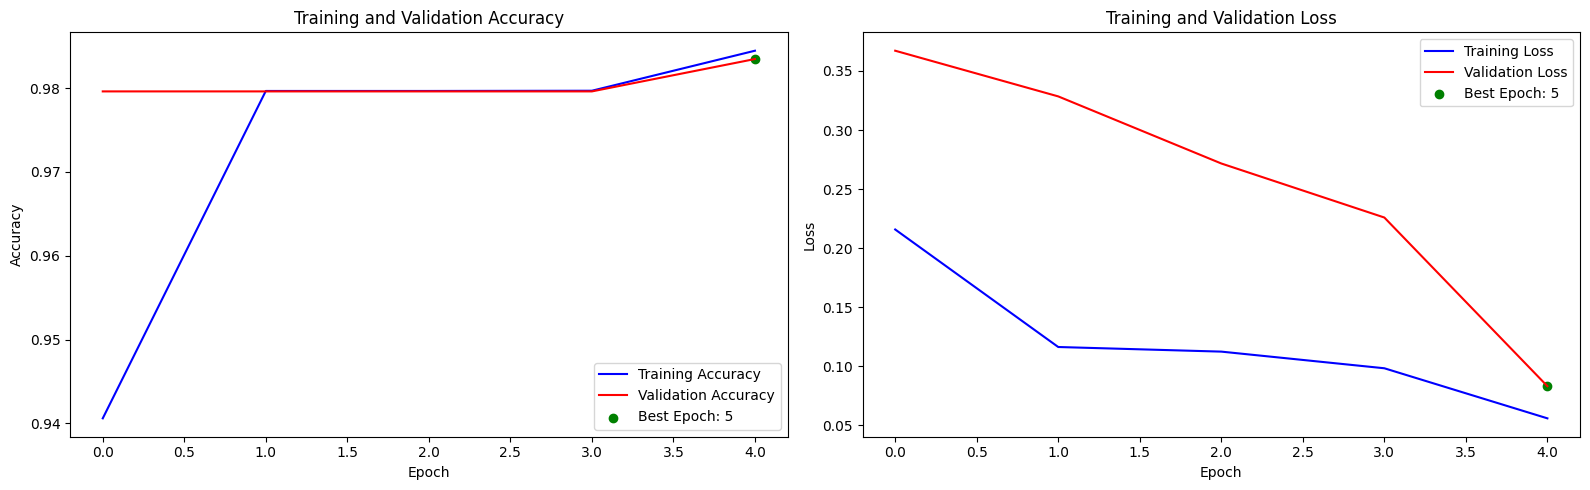

In [30]:
# Get the epoch with the highest validation accuracy
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1

# Create a subplot with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(16,5))

# Plot training and validation accuracy
axs[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
axs[0].scatter(best_epoch - 1, history.history['val_accuracy'][best_epoch - 1], color='green', label=f'Best Epoch: {best_epoch}')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend()


# Plot training and validation loss
axs[1].plot(history.history['loss'], label='Training Loss', color='blue')
axs[1].plot(history.history['val_loss'], label='Validation Loss', color='red')
axs[1].scatter(best_epoch - 1, history.history['val_loss'][best_epoch - 1], color='green',label=f'Best Epoch: {best_epoch}')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Test Accuracy</p>

In [32]:
# Evaluate Test Data
model.evaluate(X_test_padded, y_test_processed)

292/292 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.9835 - loss: 0.0830


[0.08297595381736755, 0.983474612236023]

In [33]:
# Predictions On Test For Confustion Matrix
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test_padded)
y_pred = np.argmax(y_pred, axis=1)

292/292 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step


<Axes: >

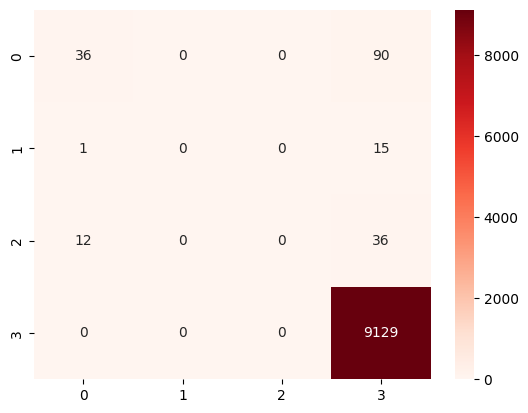

In [35]:
cm = confusion_matrix(y_test_processed, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

<Axes: >

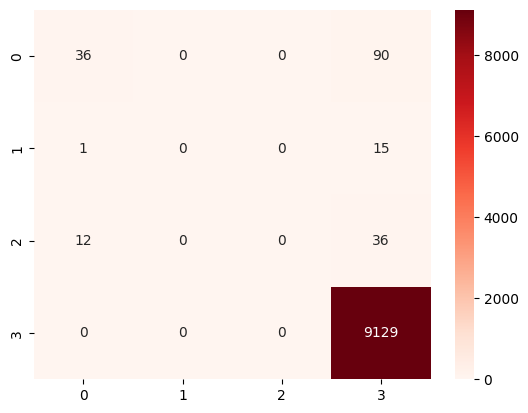

In [37]:
cm = confusion_matrix(y_test_processed, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import GRU, Dense

# Assuming X_train_padded, y_train_processed, X_test_padded are prepared
# (These variables are available in the kernel state from previous cells)
# maxlen is also available (from cell zhtCjxKKQgts)

predictions = []
num_models = 5

# Reshape X_train_padded and X_test_padded to be 3D for GRU input
# Current shape: (num_samples, maxlen) -> Desired shape: (num_samples, maxlen, 1)
X_train_reshaped = X_train_padded.reshape(X_train_padded.shape[0], X_train_padded.shape[1], 1)
X_test_reshaped = X_test_padded.reshape(X_test_padded.shape[0], X_test_padded.shape[1], 1)


for i in range(num_models):
    model = Sequential([
        # input_shape for GRU should be (timesteps, features)
        # Here, timesteps is maxlen (X_train_padded.shape[1]) and features is 1.
        GRU(64, input_shape=(maxlen, 1)), # Use maxlen directly from kernel state
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse') # Keep user's original loss function

    # Use the reshaped padded data for training and prediction
    model.fit(X_train_reshaped, y_train_processed, epochs=10, verbose=0)

    # Predict using the reshaped padded data
    preds = model.predict(X_test_reshaped)
    predictions.append(preds.flatten())

# Convert to numpy array and calculate mean and std
predictions = np.array(predictions)
mean_pred = np.mean(predictions, axis=0)
std_pred = np.std(predictions, axis=0)

print("Standard Deviations:", std_pred)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Standard Deviations: [0.02898301 0.02458368 0.02356729 ... 0.02242693 0.0257669  0.02522893]


In [40]:
print(" mean_pred:", mean_pred)

 mean_pred: [2.980706  2.987185  2.9754405 ... 2.9738503 2.9817834 2.9487908]


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">The End</p>